# Isoprene Sensitivity Studies

---
Last modified: February 6th, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of isoprene/water vapor/aerosols/etc.

This notebook is coded in Julia.

In [1]:
# Activate Julia packages
using Pkg;
using Revise;

Pkg.activate("vSmartMOM_ISOP.jl");
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("vSmartMOM_ISOP.jl/src/vSmartMOM.jl");

# Other imports
using Statistics, PlutoUI, Polynomials, PlotlyBase, Plots, LazyArtifacts, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
using FiniteDiff;

include("helper_functions.jl");

default(fontfamily="Helvetica");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl`
Precompiling project...
   6696.3 ms  ✓ vSmartMOM
  1 dependency successfully precompiled in 8 seconds. 392 already precompiled.
  1 dependency had output during precompilation:
┌ vSmartMOM
│  WARNING: method definition for elemental! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/elemental_canopy.jl:7 declares type variable M but does not use it.
│  WARNING: method definition for interaction_hdrf! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/interaction_hdrf.jl:9 declares type variable FT2 but does not use it.
│  WARNING: method definition for interaction_hdrf_canopy! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/interaction_hdrf.jl:47 declares type variable FT2 but does not use it.
│  WARNING: method definition for interaction_hdrf_canopy! at /Users/jamesyoon/Documents/Radiative_Tran

In [2]:
"Reduce profile dimensions"
function reduce_profile(n::Int, profile::AtmosphericProfile)
    @unpack lat, lon, psurf = profile
    FT = eltype(profile.T)
    # New rough half levels (boundary points)
    a = range(0, maximum(profile.p), length=n + 1)
    T = zeros(FT, n);
    q = zeros(FT, n);
    p_full = zeros(FT, n);
    p_levels = zeros(FT, n + 1);
    vmr_h2o  = zeros(FT, n);
    vcd_dry  = zeros(FT, n);
    vcd_h2o  = zeros(FT, n);

    for i = 1:n
        ind = findall(a[i] .< profile.p .<= a[i + 1]);
        p_levels[i] = profile.p_levels[ind[1]]
        p_levels[i + 1] = profile.p_levels[ind[end]]
        p_full[i] = mean(profile.p_levels[ind])
        T[i] = mean(profile.T[ind])
        q[i] = mean(profile.q[ind])
        vmr_h2o[i] = mean(profile.vmr_h2o[ind])
        vcd_dry[i] = sum(profile.vcd_dry[ind])
        vcd_h2o[i] = sum(profile.vcd_h2o[ind])
    end

    return AtmosphericProfile(lat, lon, psurf, T, q, p_full, p_levels, vmr_h2o, vcd_dry, vcd_h2o)
end;

### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [3]:
function retrieve_merra2_conditions(date, startTime, lat, lon)
    # Feel free to change the MERRA2 file and folder paths
    MerraFile = "MERRA2_400.inst6_3d_ana_Nv." * date * ".nc4"
    MerraFolder = "MERRA2/"
    MerraFilePath = joinpath(MerraFolder, MerraFile)

    # These files have 00, 06, 12 or 18 in UTC, i.e. 6 hourly data stacked together
    hour = parse(Int, chop(startTime));
    hour_index = Int(hour / 6);

    # Read atmos profile (from helperfunctions.jl)
    return read_atmos_profile(MerraFilePath, lat, lon, hour_index);
end

# Parameters for atmospheric profile
date = "20190701"
startTime = "06z"
lat = 2.
lon = 100.

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);
merra2_profile = reduce_profile(4, merra2_profile)

pressures = merra2_profile.p_levels ./ 100; # Convert to hPa
pressures_midpoints = merra2_profile.p ./ 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q .* 1000; # Convert from kg/kg (in MERRA2) to g/kg;

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]



In [4]:
current_profile = specific_humidity ./ 1000 .* 1e-7; # Get current isoprene vertical profile
total_column = merra2_profile.vcd_dry .* current_profile; # Multiply by vertical column density
total_column = sum(total_column) # Sum for the total column
println("The total column is $(total_column) molec cm-2")

mean_vmr = total_column / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr * 1e9) ppbv")

current_profile_x5 = specific_humidity ./ 1000 .* 1e-7 .* 5; # Get current isoprene vertical profile
total_column_x5 = merra2_profile.vcd_dry .* current_profile_x5; # Multiply by vertical column density
total_column_x5 = sum(total_column_x5) # Sum for the total column
println("The total column is $(total_column_x5) molec cm-2")

mean_vmr_x5 = total_column_x5 / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr_x5 * 1e9) ppbv")

The total column is 1.0713622913766074e16 molec cm-2
The equivalent constant VMR is 0.5095802019910322 ppbv
The total column is 5.356811456883037e16 molec cm-2
The equivalent constant VMR is 2.547901009955161 ppbv


In [5]:
import InstrumentOperator: FTSInstrument, create_instrument_kernel, FixedKernelInstrument, conv_spectra

ν_min = 890.
ν_max = 910.
Δν = 0.01
ν = ν_min:Δν:ν_max

x = -5:Δν:5
fov = 16.8 #mrads
mopd = 0.8 #cm
FTS = FTSInstrument(0.8, fov * 1e-3, 0.)
unapodized_fts = create_instrument_kernel(FTS, x, 900.0)

p = plot(x, unapodized_fts.parent,label="CrIS Unapodized FTS Lineshape",lw=2, dpi = 300, title = "CrIS Unapodized FTS Instrument Line Shape \n(FOV = 16.8 mrads, MOPD = 0.8 cm)")
ylabel!("Channel Response Function")
xlabel!("σ (cm^-1)")
# savefig(p, "Figures/unapodized_instrument_kernel.png")

margin = 0
sampling = 0.625
cris_instrument_kernel = FixedKernelInstrument(unapodized_fts, collect(ν_min+margin:sampling:ν_max-margin))

┌ Info: Center of OffsetArrays is 
│   minimum(abs.(grid_x)) = 0.0
└ @ InstrumentOperator /Users/jamesyoon/.julia/packages/InstrumentOperator/JJWCH/src/prepare_ils.jl:39


(Θ, β) = (0.12700800000000004, 0.0)


FixedKernelInstrument{Float64}([-0.0001938027449118005, -0.00022515990131574464, -0.0002560745521885616, -0.0002864668905839412, -0.0003162580989748737, -0.0003453705508071965, -0.00037372800988458884, -0.00040125582708002165, -0.0004278811338732687, -0.00045353303222005073  …  -0.00011292824838757243, -9.056541516724512e-5, -7.058344327000462e-5, -5.30230478386403e-5, -3.791869420702852e-5, -2.529853680148194e-5, -1.5184374041206004e-5, -7.5916192866803565e-6, -2.5292878448332848e-6, -1.463672932855431e-18], [890.0, 890.625, 891.25, 891.875, 892.5, 893.125, 893.75, 894.375, 895.0, 895.625  …  904.375, 905.0, 905.625, 906.25, 906.875, 907.5, 908.125, 908.75, 909.375, 910.0])

### We can finally run the model!

In [6]:
FT = Float64
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.float_type = FT

# Prior State vector
x = ones(length(specific_humidity)) ./ 1e9 # ./ 1000 * 28.96/18.02 .* 1000
# x = ones(length(specific_humidity)) ./ 1000 * 28.96/18.02 .* 1000
x

4-element Vector{Float64}:
 1.0e-9
 1.0e-9
 1.0e-9
 1.0e-9

In [7]:
# Runner is used to set AD fields as duals
function runner(x, parameters=parameters)
    parameters.T = temperatures;
    parameters.p = pressures;
    parameters.q = specific_humidity;
    parameters.absorption_params.vmr["H2O"] = 0; # convert to kg/kg from g/kg, then mol/mol
    parameters.absorption_params.vmr["ISOP"] = x; # convert to kg/kg from g/kg, then mol/mol

    model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
    model_output = vSmartMOM.CoreRT.rt_run(model); # Run the model
    model_output = conv_spectra(cris_instrument_kernel, ν, model_output[1][1,1,:]);
    return model_output;
end

runner (generic function with 2 methods)

In [8]:
test = FiniteDiff.finite_difference_jacobian(runner,x)

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.000388274682120417, 0.0003916634513431471, 0.000395] for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [1.0e-9, 1.0e-9, 1.0e-9, 1.0e-9] for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


...

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               12.8s /  51.3%           13.0GiB /  79.9%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    3.77s   57.3%   943ms   2.79GiB   26.9%   715MiB
RT Kernel                        12    2.60s   39.5%   217ms   6.91GiB   66.6%   590MiB
  doubling                       12    2.28s   34.6%   190ms   6.19GiB   59.6%   529MiB
    Batch Inv Doubling          132    931ms   14.2%  7.06ms   2.61GiB   25.1%  20.2MiB
  interaction                     9    213ms    3.2%  23.7ms    729MiB    6.9%  81.0MiB
    interaction inv2           

33×4 Matrix{Float64}:
  -61500.3        -41623.1        -17869.8   493.746
  -63638.7        -42980.2        -18476.7   509.816
  -67177.6        -45680.4        -19739.9   545.607
  -88543.1        -60031.3        -25894.8   708.297
      -1.29193e5  -87105.8        -37390.6   996.02
      -1.98489e5      -1.32829e5  -56678.2  1449.04
      -2.6794e5       -1.76318e5  -74153.4  1825.25
      -1.04535e5  -71723.5        -31211.4   837.406
  -51238.5        -35531.9        -15617.3   443.136
  -51107.3        -34845.9        -15096.7   418.722
       ⋮                                    
 -122265.0        -82204.9        -35220.9   927.257
      -1.40864e5  -95651.6        -41319.0  1081.1
      -2.32783e5      -1.53498e5  -64660.0  1589.18
  -98960.0        -67907.9        -29560.9   786.575
  -53918.6        -37309.1        -16378.0   456.995
  -59191.6        -40235.8        -17390.0   468.718
  -58966.6        -40018.1        -17276.3   471.731
  -59974.6        -40539.9        -174

4-element Vector{Float64}:
  0.016244077866212455
  2.2620646536017412
  8.994985356323262
 21.292170846391684

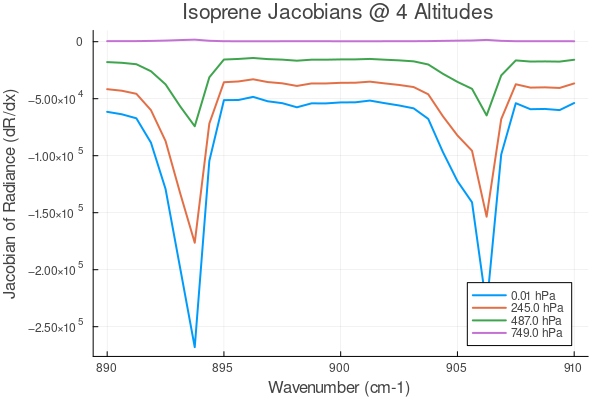

In [9]:
plot(cris_instrument_kernel.ν_out, test[:,1], label = "$(pressures[1]) hPa", lw = 2)
plot!(cris_instrument_kernel.ν_out, test[:,2], label = "$(round(pressures[2])) hPa", lw = 2)
plot!(cris_instrument_kernel.ν_out, test[:,3], label = "$(round(pressures[3])) hPa", lw = 2)
plot!(cris_instrument_kernel.ν_out, test[:,4], label = "$(round(pressures[4])) hPa", lw = 2)

title!("Isoprene Jacobians @ 4 Altitudes")
xlabel!("Wavenumber (cm-1)")
ylabel!("Jacobian of Radiance (dR/dx)")

In [41]:
FiniteDiff.finite_difference_jacobian(runner,x)

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.000388274682120417, 0.0003916634513431471, 0.000395] for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [1.6244077866212456e-5, 0.002262064653601741, 0.008994985356323263, 0.021292170846391685] for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


...

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               12.8s /  52.6%           13.0GiB /  79.9%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    3.62s   53.9%   904ms   2.79GiB   26.9%   715MiB
RT Kernel                        12    2.77s   41.3%   231ms   6.91GiB   66.6%   590MiB
  doubling                       12    2.44s   36.3%   203ms   6.19GiB   59.6%   529MiB
    Batch Inv Doubling          132    946ms   14.1%  7.17ms   2.61GiB   25.1%  20.2MiB
  interaction                     9    223ms    3.3%  24.8ms    729MiB    6.9%  81.0MiB
    interaction inv1 bla       

33×4 Matrix{Float64}:
 0.282904   2.32831e-10  0.0  0.0
 0.273812   0.0          0.0  0.0
 0.256415   2.32831e-10  0.0  0.0
 0.19774    0.0          0.0  0.0
 0.132783   0.0          0.0  0.0
 0.0883282  0.0          0.0  0.0
 0.0677996  0.0          0.0  0.0
 0.195389   0.0          0.0  0.0
 0.308891   0.0          0.0  0.0
 0.339252   0.0          0.0  0.0
 ⋮                            
 0.132135   0.0          0.0  0.0
 0.117991   0.0          0.0  0.0
 0.0701075  0.0          0.0  0.0
 0.190994   0.0          0.0  0.0
 0.27482    0.0          0.0  0.0
 0.284177   0.0          0.0  0.0
 0.26502    0.0          0.0  0.0
 0.272577   0.0          0.0  0.0
 0.28802    0.0          0.0  0.0

In [59]:
length(x)

4

UndefVarError: UndefVarError: `gradient` not defined in `FiniteDiff`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Interpolations.

In [68]:
gr = Array{Float64}(undef, length(x))
buffer = Array{Float64}(undef, length(x))

FiniteDiff.gradient!(gr, runner!, x, buffer)

UndefVarError: UndefVarError: `gradient!` not defined in `FiniteDiff`
Suggestion: check for spelling errors or missing imports.

runner! (generic function with 2 methods)

In [142]:
x = specific_humidity ./ 1000 * 28.96/18.02
result = DiffResults.JacobianResult(zeros(length(cris_instrument_kernel.ν_out)), x);

In [143]:
ForwardDiff.jacobian!(result, runner!, x);

MethodError: MethodError: no method matching Float64(::ForwardDiff.Dual{ForwardDiff.Tag{typeof(runner!), Float64}, Float64, 4})
The type `Float64` exists, but no method is defined for this combination of argument types when trying to construct it.

Closest candidates are:
  (::Type{T})(::Real, !Matched::RoundingMode) where T<:AbstractFloat
   @ Base rounding.jl:265
  (::Type{T})(::T) where T<:Number
   @ Core boot.jl:900
  Float64(!Matched::UInt8)
   @ Base float.jl:245
  ...


In [144]:
# result = DiffResults.JacobianResult(zeros(length(cris_instrument_kernel.ν_out)), jacobian_array);
# @time ForwardDiff.jacobian!(result, forward_model, jacobian_array);

# = DiffResults.jacobian(result);
# F = DiffResults.value(result);

In [145]:
# plot(inst.ν_out,F , label="F(x)")
# plot(inst.ν_out,K[:,2:2:15], lw=2, alpha=0.5, label="dF/dx" )